In [60]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from dataloader import RealisticScoreDataset

import torch as th
import numpy as np

real_data_paths = ['/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/real_images/ffhq_256/train/']
gen_data_paths = [
    '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot1_srcC/', 
    '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot1_maxC/',
    '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_srcC/', 
    '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_maxC/',
]

train_dataset = RealisticScoreDataset(real_data_paths, gen_data_paths, num_subjects_real=5000, num_subjects_gen=250, frames_per_subject=5)
train_dataloader = th.utils.data.DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True, num_workers=32)
train_batch = next(iter(train_dataloader))
print(train_batch['latent'].shape)

train_latent = train_batch['latent']
train_latent_norm = train_batch['latent_norm']
train_labels = train_batch['label']

Seed set to 47


############### Initializing RealisticScoreDataset ###############
[#] Total real subjects:  5000
[#] Total real frames:  5000
[#] Total generated subjects:  1000
[#] Total generated frames:  5000
[#] Total images (real + gen):  10000
############### Finished initializing RealisticScoreDataset ###############
torch.Size([10000, 512])


In [44]:
th.unique(train_batch['latent_mean'], dim=0)

tensor([[-0.0041,  0.0026, -0.0315,  ...,  0.0173,  0.0232, -0.0083],
        [-0.0009,  0.0027, -0.0216,  ...,  0.0072, -0.0109,  0.0031],
        [ 0.0013,  0.0103, -0.0127,  ...,  0.0085,  0.0104, -0.0052],
        [ 0.0023,  0.0006, -0.0343,  ...,  0.0098, -0.0055,  0.0014],
        [ 0.0051,  0.0067, -0.0114,  ..., -0.0074,  0.0065, -0.0059]])

100%|██████████| 10000/10000 [00:08<00:00, 1217.55it/s]


0.004161815624684095


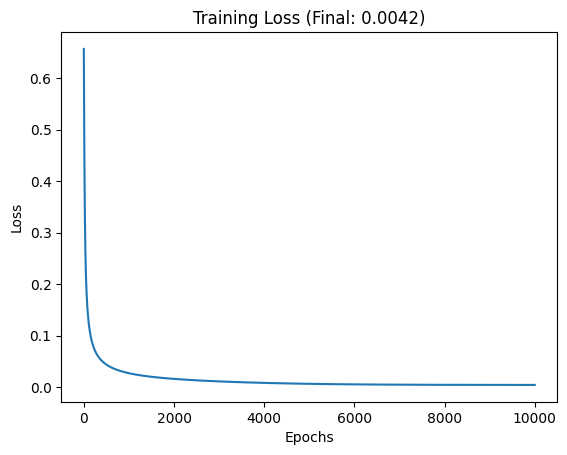

In [61]:
import importlib
import cls
importlib.reload(cls)
import matplotlib.pyplot as plt
device = "cuda:0"
linear_cls = cls.CLS(input_dim=512, lr=1e-3, weight_decay=1e-4, n_epochs=10000, device=device)
linear_cls = linear_cls.to(device)

# Train
# linear_cls.fit(train_latent_norm, train_labels)
train_latent_global_norm = (train_latent - train_latent.mean(dim=0, keepdim=True)) / train_latent.std(dim=0, keepdim=True)
linear_cls.fit(train_latent_global_norm, train_labels)
# linear_cls.fit(train_latent, train_labels)
# Plot loss
print(linear_cls.loss_)
plt.plot(linear_cls.training_loss)    
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title(f'Training Loss (Final: {linear_cls.loss_:.4f})')
plt.show()


In [62]:
# Evaluate on train set
print("Classifier's coef_ shape: ", linear_cls.coef_.shape)
cls_proj = (train_latent_global_norm @ linear_cls.coef_.T) + linear_cls.intercept_
train_pred = (cls_proj > 0).reshape(-1).cpu().numpy()
# train_pred = linear_cls.predict(train_latent_global_norm)
print("[#] Train accuracy (cls): ", np.mean((train_pred.flatten() == (train_labels==1.0).cpu().numpy())))

# print("Linear layer: ", linear_cls.linear(train_latent_global_norm.to(device)))
# print("Projection cls_proj: ", cls_proj)
# print("Projection cls_proj + intercept: ", cls_proj + linear_cls.intercept_)

Classifier's coef_ shape:  (1, 512)
[#] Train accuracy (cls):  0.9998


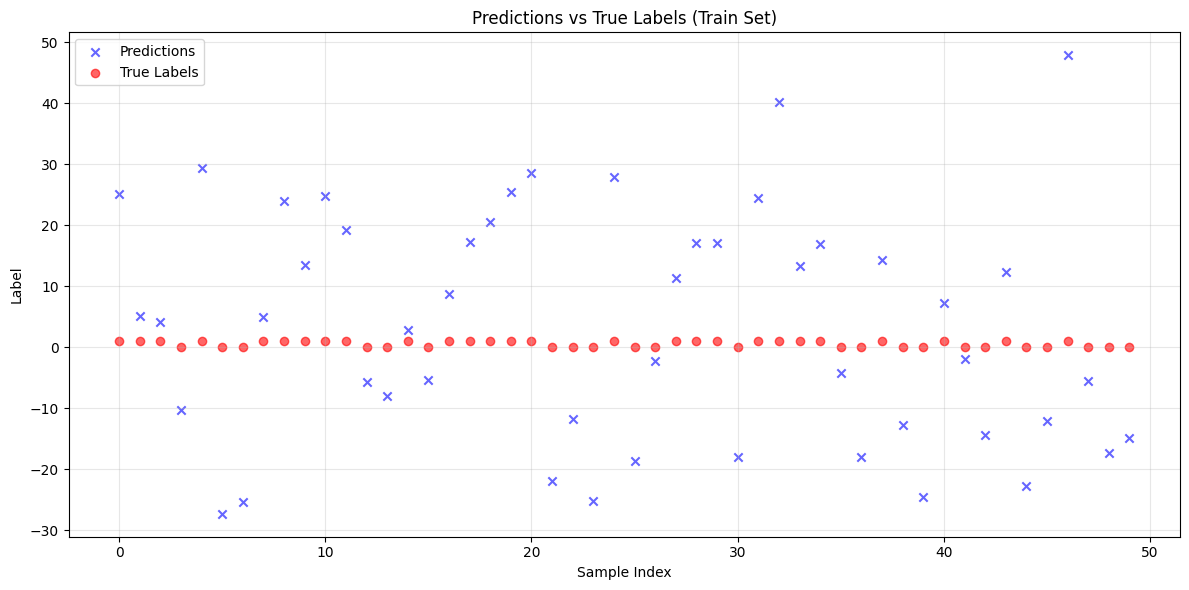

In [63]:
import matplotlib.pyplot as plt

n = 50
x = range(n)

plt.figure(figsize=(12, 6))
plt.scatter(x, cls_proj[:n], c='blue', label='Predictions', alpha=0.6, marker='x')
plt.scatter(x, train_labels[:n], c='red', label='True Labels', alpha=0.6, marker='o')

plt.xlabel('Sample Index')
plt.ylabel('Label')
plt.title('Predictions vs True Labels (Train Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [70]:
test_real_data_paths = [
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/real_images/ffhq_256/valid/'
]
test_gen_data_paths = [
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot1_srcC/', 
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot1_maxC/',
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_srcC/', 
    # '/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_maxC/',
    # "/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images_paper/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_0.6C_rot1_0.7sh/",
    # "/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images_paper/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_srcC_rot2_1.0sh/",
    "/data/mint/DPM_Dataset/TPAMI_MajorRevision/Realsitric_Score/gen_images_paper/log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_1.0C_rot2_1.0sh/"
]
test_dataset = RealisticScoreDataset(test_real_data_paths, test_gen_data_paths, num_subjects_real=5000, num_subjects_gen=999, frames_per_subject=30, seed=1234)
test_dataloader = th.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset))
test_batch = next(iter(test_dataloader))
print(test_batch['latent'].shape)

test_latent = test_batch['latent']
test_latent_global_norm = (test_latent - train_latent.mean(dim=0, keepdim=True)) / train_latent.std(dim=0, keepdim=True)
test_labels = test_batch['label']

Seed set to 1234


############### Initializing RealisticScoreDataset ###############
[#] Total real subjects:  0
[#] Total real frames:  0
[#] Total generated subjects:  999
[#] Total generated frames:  18981
[#] Total images (real + gen):  18981
############### Finished initializing RealisticScoreDataset ###############
torch.Size([18981, 512])


[#] Test accuracy (cls):  0.361150624308519
[#] #N pred=1:  12126 / 18981
[#] #N pred=0:  6855 / 18981


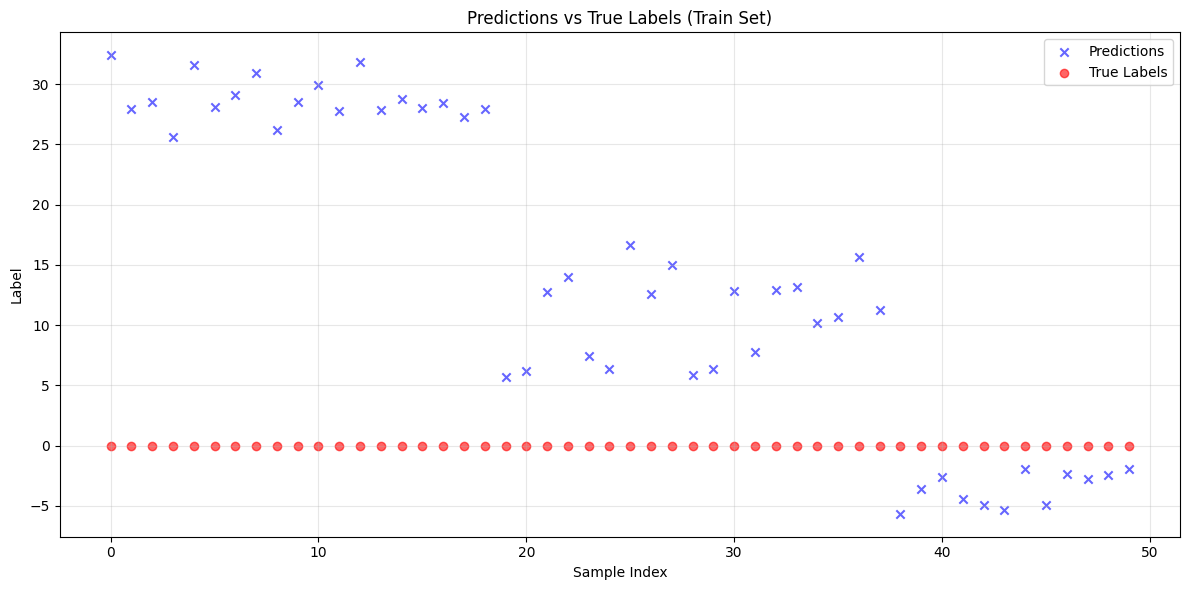

18981


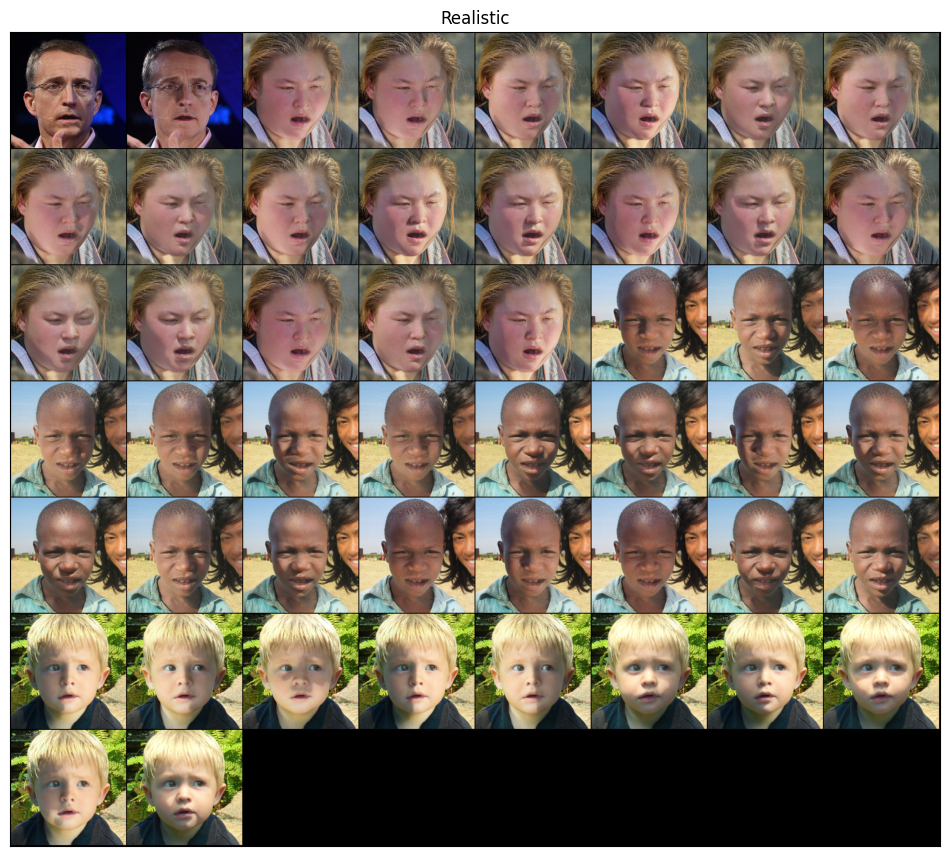

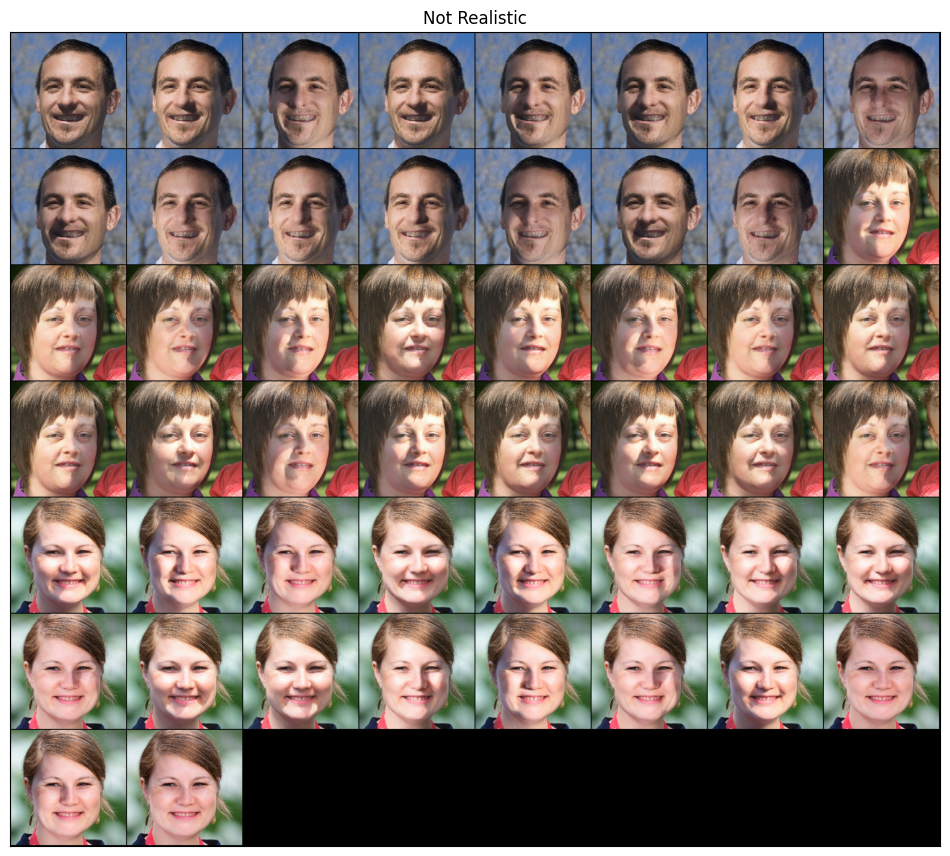

In [72]:
# Evaluate on test set
cls_proj = linear_cls.linear(test_latent_global_norm.to(device))
cls_proj_npy = cls_proj.detach().cpu().numpy()
test_pred = (th.sigmoid(cls_proj) > 0.5).squeeze()
print("[#] Test accuracy (cls): ", np.mean((test_pred.flatten().cpu().numpy() == (test_labels==1.0).cpu().numpy())))
print("[#] #N pred=1: ", th.sum(test_pred).item(), "/", len(test_pred))
print("[#] #N pred=0: ", th.sum(~test_pred).item(), "/", len(test_pred))

n = 50
x = range(n)

plt.figure(figsize=(12, 6))
plt.scatter(x, cls_proj_npy[:n], c='blue', label='Predictions', alpha=0.6, marker='x')
plt.scatter(x, test_labels[:n], c='red', label='True Labels', alpha=0.6, marker='o')

plt.xlabel('Sample Index')
plt.ylabel('Label')
plt.title('Predictions vs True Labels (Train Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Get where cls_proj = 1
real_indices = np.where(test_pred.cpu().numpy() == True)[0]
gen_indices = np.where(test_pred.cpu().numpy() == False)[0]
# real = [test_batch['image_path'][x] for x in real_indices]
# does_not_look_realistic = [test_batch['image_path'][x] for x in gen_indices]
print(len(test_batch['image_path']))
# Show images as a grid
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torchvision.transforms.functional as F
from torchvision.utils import make_grid


plt.rcParams["savefig.bbox"] = 'tight'

def show(imgs, figsize=(12, 12), title=''):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    plt.title(title)
    fig.set_size_inches(figsize)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

show(make_grid([th.tensor(np.array(Image.open(test_batch['image_path'][x]))).permute(2, 0, 1) for x in real_indices[200:250]]), title='Realistic')
show(make_grid([th.tensor(np.array(Image.open(test_batch['image_path'][x]))).permute(2, 0, 1) for x in gen_indices[200:250]]), title='Not Realistic')